# Fake News Detection Using Machine Learning

# Internship Project

**Intern:** Sharanya Baranwal

**Tools Used:**
- Python
- Jupyter Notebook
- Pandas
- Scikit-learn
- Matplotlib
- Seaborn

---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df = pd.read_csv("FA-KES-Dataset.csv", encoding="latin1")
print (df.head())
print (df.shape)
print (df.info())

      unit_id                                      article_title  \
0  1914947530  Syria attack symptoms consistent with nerve ag...   
1  1914947532  Homs governor says U.S. attack caused deaths b...   
2  1914947533    Death toll from Aleppo bomb attack at least 112   
3  1914947534        Aleppo bomb blast kills six Syrian state TV   
4  1914947535  29 Syria Rebels Dead in Fighting for Key Alepp...   

                                     article_content source       date  \
0  Wed 05 Apr 2017 Syria attack symptoms consiste...    nna   4/5/2017   
1  Fri 07 Apr 2017 at 0914 Homs governor says U.S...    nna   4/7/2017   
2  Sun 16 Apr 2017 Death toll from Aleppo bomb at...    nna  4/16/2017   
3  Wed 19 Apr 2017 Aleppo bomb blast kills six Sy...    nna  4/19/2017   
4  Sun 10 Jul 2016 29 Syria Rebels Dead in Fighti...    nna  7/10/2016   

  location  labels  
0    idlib       0  
1     homs       0  
2   aleppo       0  
3   aleppo       0  
4   aleppo       0  
(804, 7)
<class 'pan

In [3]:
print (df.isnull().sum())
print (df.columns)
print (df['labels'].value_counts())
print (df.loc[0])

unit_id            0
article_title      0
article_content    0
source             0
date               0
location           0
labels             0
dtype: int64
Index(['unit_id', 'article_title', 'article_content', 'source', 'date',
       'location', 'labels'],
      dtype='object')
labels
1    426
0    378
Name: count, dtype: int64
unit_id                                                   1914947530
article_title      Syria attack symptoms consistent with nerve ag...
article_content    Wed 05 Apr 2017 Syria attack symptoms consiste...
source                                                           nna
date                                                        4/5/2017
location                                                       idlib
labels                                                             0
Name: 0, dtype: object


In [4]:
print(df["article_title"][0])
print(df["article_content"][0])

Syria attack symptoms consistent with nerve agent use WHO
Wed 05 Apr 2017 Syria attack symptoms consistent with nerve agent use WHO. Victims of a suspected chemical attack in Syria appeared to show symptoms consistent with reaction to a nerve agent the World Health Organization said on Wednesday. "Some cases appear to show additional signs consistent with exposure to organophosphorus chemicals a category of chemicals that includes nerve agents" WHO said in a statement putting the death toll at at least 70. The United States has said the deaths were caused by sarin nerve gas dropped by Syrian aircraft. Russia has said it believes poison gas had leaked from a rebel chemical weapons depot struck by Syrian bombs. Sarin is an organophosporus compound and a nerve agent. Chlorine and mustard gas which are also believed to have been used in the past in Syria are not. A Russian Defence Ministry spokesman did not say what agent was used in the attack but said the rebels had used the same chemica

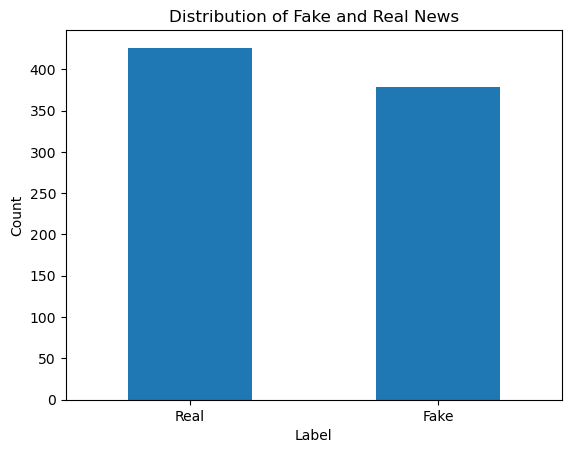

In [5]:
df["labels"].value_counts().plot(kind="bar")

plt.title("Distribution of Fake and Real News")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(ticks=[0, 1], labels=["Real", "Fake"], rotation=0)

plt.show()

In [6]:
from sklearn.model_selection import train_test_split
x=df['article_content']
y=df['labels']
x_train, x_test, y_train, y_test = train_test_split (x, y, test_size = 0.2, random_state = 42)
print("Training data:", x_train.shape)
print("Testing data :", x_test.shape)

Training data: (643,)
Testing data : (161,)


## TF-IDF Vectorization

Machine learning models cannot understand text directly. Therefore, the news articles are converted into numerical feature vectors using the TF-IDF (Term Frequency-Inverse Document Frequency) technique. This gives more importance to meaningful words while reducing the importance of common words.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words = 'english', max_df = 0.7)
x_train_tfidf = tfidf.fit_transform(x_train)
x_test_tfidf = tfidf.transform(x_test)
print("Training Matrix Shape:", x_train_tfidf.shape)
print("Testing Matrix Shape:", x_test_tfidf.shape)

Training Matrix Shape: (643, 8764)
Testing Matrix Shape: (161, 8764)


## Passive Aggressive Classifier

In this project, we use the Passive Aggressive Classifier. It is suitable for text classification problems because it updates itself whenever it makes an incorrect prediction while making minimal changes for correct predictions.

In [8]:
from sklearn.linear_model import PassiveAggressiveClassifier
pac = PassiveAggressiveClassifier ( max_iter = 1000, random_state = 42)
pac.fit(x_train_tfidf, y_train)

,C,1.0
,fit_intercept,True
,max_iter,1000
,tol,0.001
,early_stopping,False
,validation_fraction,0.1
,n_iter_no_change,5
,shuffle,True
,verbose,0
,loss,'hinge'
,n_jobs,None


In [9]:
pac_pred = pac.predict(x_test_tfidf)
from sklearn.metrics import accuracy_score
pac_accuracy = accuracy_score(y_test, pac_pred)
print(f"Passive Aggressive Classifier Accuracy: {pac_accuracy*100:.2f}%")
from sklearn.metrics import classification_report
print(classification_report(y_test, pac_pred))

Passive Aggressive Classifier Accuracy: 57.14%
              precision    recall  f1-score   support

           0       0.52      0.49      0.50        72
           1       0.61      0.64      0.62        89

    accuracy                           0.57       161
   macro avg       0.56      0.56      0.56       161
weighted avg       0.57      0.57      0.57       161



In [10]:
from sklearn.metrics import confusion_matrix
pac_cm = confusion_matrix(y_test, pac_pred)
print(pac_cm)

[[35 37]
 [32 57]]


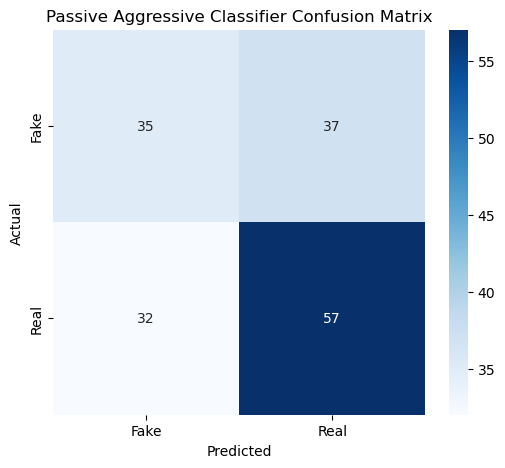

In [11]:
plt.figure(figsize=(6,5))

sns.heatmap(
    pac_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Passive Aggressive Classifier Confusion Matrix")

plt.show()

## Logistic Regression Model

Logistic Regression is a supervised machine learning algorithm widely used for binary classification problems. In this project, it is used to classify news articles as fake or real based on their TF-IDF feature vectors.

In [12]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression (random_state = 42)
lr.fit (x_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [13]:
lr_pred = lr.predict (x_test_tfidf)
lr_accuracy = accuracy_score(y_test, lr_pred)
print(f"Logistic Regression Accuracy: {lr_accuracy*100:.2f}%")
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 55.28%
              precision    recall  f1-score   support

           0       0.50      0.42      0.45        72
           1       0.58      0.66      0.62        89

    accuracy                           0.55       161
   macro avg       0.54      0.54      0.54       161
weighted avg       0.55      0.55      0.55       161



In [14]:
lr_cm = confusion_matrix(y_test, lr_pred)
print(lr_cm)

[[30 42]
 [30 59]]


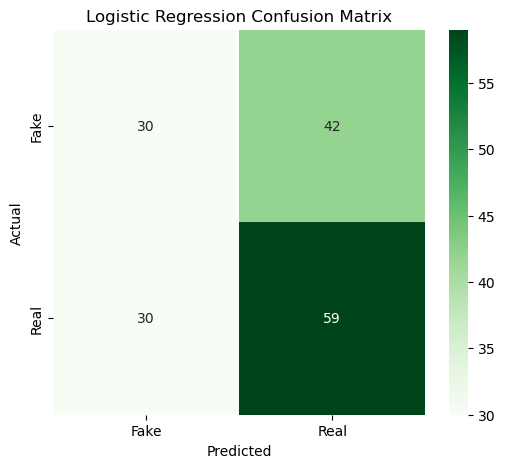

In [15]:
plt.figure(figsize=(6,5))

sns.heatmap(
    lr_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

## Linear Support Vector Machine (Linear SVM)

Linear Support Vector Machine (Linear SVM) is a supervised machine learning algorithm widely used for text classification. It finds the optimal boundary (hyperplane) that best separates different classes. It often performs well on high-dimensional text data represented using TF-IDF features.

In [16]:
from sklearn.svm import LinearSVC
svm = LinearSVC (random_state = 42)
svm.fit (x_train_tfidf, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,42


In [17]:
svm_pred = svm.predict(x_test_tfidf)
svm_accuracy = accuracy_score (y_test, svm_pred)
print(f"Linear SVM Accuracy: {svm_accuracy*100:.2f}%")
print(classification_report(y_test, svm_pred))

Linear SVM Accuracy: 55.90%
              precision    recall  f1-score   support

           0       0.51      0.50      0.50        72
           1       0.60      0.61      0.60        89

    accuracy                           0.56       161
   macro avg       0.55      0.55      0.55       161
weighted avg       0.56      0.56      0.56       161



In [18]:
svm_cm = confusion_matrix (y_test, svm_pred)
print (svm_cm)

[[36 36]
 [35 54]]


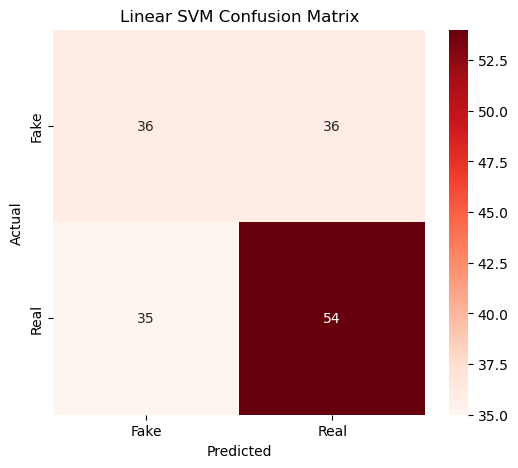

In [19]:
plt.figure(figsize=(6,5))

sns.heatmap(
    svm_cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Linear SVM Confusion Matrix")

plt.show()

## Model Comparison

| Model | Accuracy |
|--------|----------|
| Passive Aggressive Classifier | 57.14% |
| Logistic Regression | 55.28% |
| Linear SVM | 55.90% |

### Conclusion

Three machine learning algorithms were evaluated on the FA-KES dataset using the same TF-IDF features and train-test split.

Among the evaluated models, the Passive Aggressive Classifier achieved the highest accuracy of **57.14%**. Therefore, it was selected as the final model for this project.

In [20]:
News = "Plastic Island found in the ocean."
print ("News: " + News)
News_tfidf = tfidf.transform ([News])
pred = pac.predict (News_tfidf)
if pred[0]==0:
    print ("Real")
else: 
    print ("Fake")

News: Plastic Island found in the ocean.
Real
